In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from od_mimari import get_segmentation_model  # Kendi dosya ismine göre kontrol et
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Cihaz ayarı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model yükleme
model_path = "best_od.pth"
model = get_segmentation_model().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Standart Transform
test_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

C:\Users\Ayberk\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def process_fundus_v3(image_rgb, model, transform, device):
    h, w = image_rgb.shape[:2]
    
    # --- 1. OD Segmentasyonu ---
    input_tensor = transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        prediction = (output > 0.5).cpu().numpy().squeeze()
    od_mask = cv2.resize(prediction.astype(np.uint8), (w, h))
    
    # OD Merkezi ve Yaklaşık Yarıçapı
    contours, _ = cv2.findContours(od_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None
    cnt = max(contours, key=cv2.contourArea)
    M = cv2.moments(cnt)
    cx_od, cy_od = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"]))
    od_radius = int(np.sqrt(cv2.contourArea(cnt) / np.pi))

    # --- 2. MATLAB "imbinarize + bwareafilt" Mantığı (FOV Tespiti) ---
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, fov_mask = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    # Sadece en büyük dairesel alanı (gözü) tut, gürültüleri sil
    fov_contours, _ = cv2.findContours(fov_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if fov_contours:
        largest_fov = max(fov_contours, key=cv2.contourArea)
        fov_mask = np.zeros_like(fov_mask)
        cv2.drawContours(fov_mask, [largest_fov], -1, 255, -1)
    
    # Kenar yansımalarından kurtulmak için FOV'u %15 daralt (Çok Kritik!)
    fov_mask = cv2.erode(fov_mask, np.ones((51, 51), np.uint8)) 

    # --- 3. Makula Arama (Hocanın Invert + Percentile Mantığı) ---
    v_channel = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)[:, :, 2]
    blurred = cv2.medianBlur(v_channel, 25) # Filtreyi büyüttük (damarları tam silmek için)
    inverted = cv2.bitwise_not(blurred)

    # Kısıtlamalar
    inverted[fov_mask == 0] = 0
    inverted[od_mask > 0] = 0
    
    # EKSTRA: Mesafe Kısıtı (OD'den çok uzak veya çok yakın olamaz)
    y, x = np.indices((h, w))
    dist_from_od = np.sqrt((x - cx_od)**2 + (y - cy_od)**2)
    # Makula genelde 2*OD_radius ile 5*OD_radius arasındadır
    mask_distance = (dist_from_od > od_radius * 1.5) & (dist_from_od < od_radius * 6)
    inverted[~mask_distance] = 0

    # Adaptif Eşik (Percentile 98 - Daha seçici)
    valid_px = inverted[inverted > 0]
    if len(valid_px) > 0:
        thresh = np.percentile(valid_px, 98)
        _, bw = cv2.threshold(inverted, thresh, 255, cv2.THRESH_BINARY)
        
        # MATLAB: bwareaopen (küçük bölgeleri sil)
        bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, np.ones((11, 11), np.uint8))
        
        m_contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if m_contours:
            # En büyük "karanlık blobu" seç
            best_m_cnt = max(m_contours, key=cv2.contourArea)
            M_m = cv2.moments(best_m_cnt)
            macula_center = (int(M_m["m10"] / M_m["m00"]), int(M_m["m01"] / M_m["m00"]))
        else:
            _, _, _, macula_center = cv2.minMaxLoc(inverted)
    else: return None

    return {"od_center": (cx_od, cy_od), "macula_center": macula_center, "od_mask": od_mask}

12 adet resim bulundu.


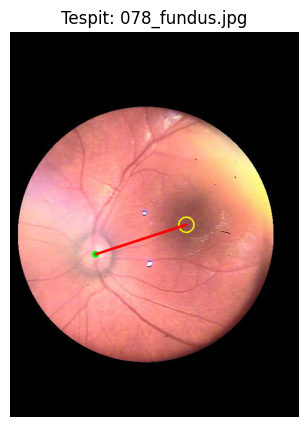

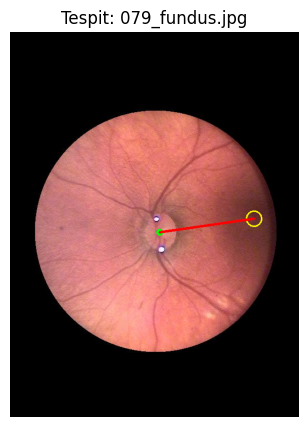

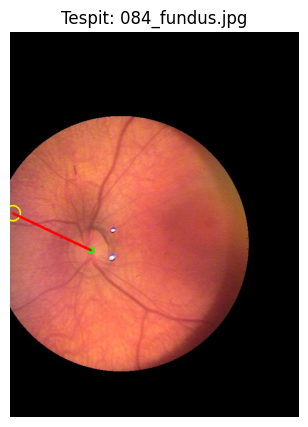

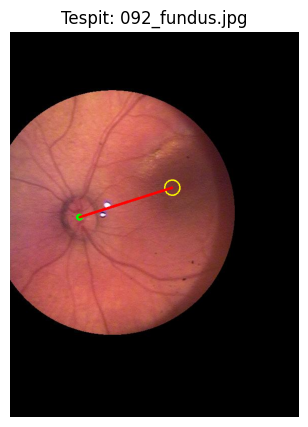

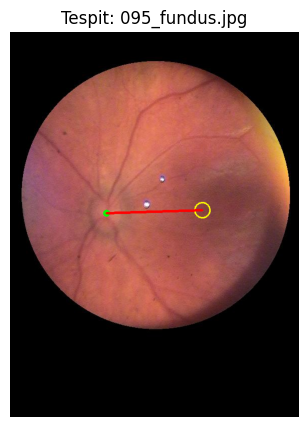

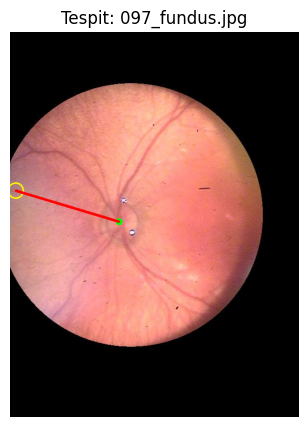

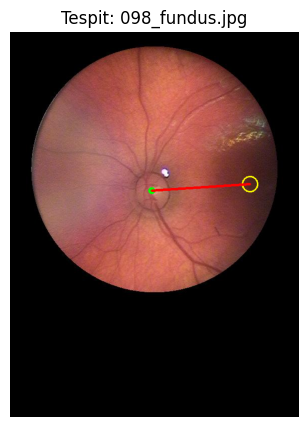

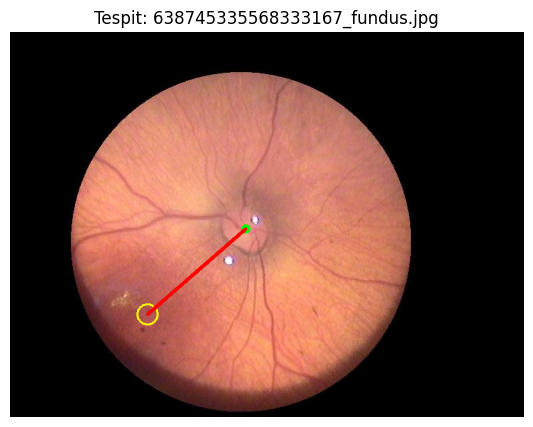

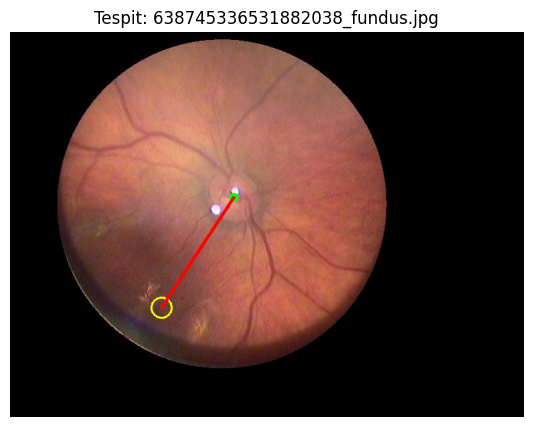

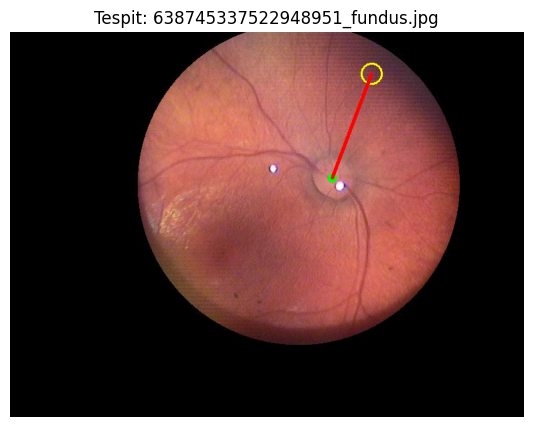

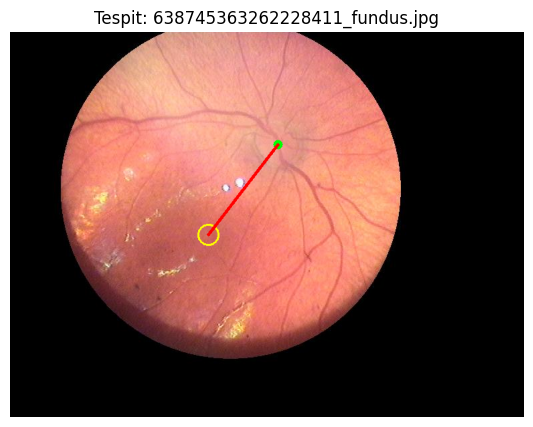

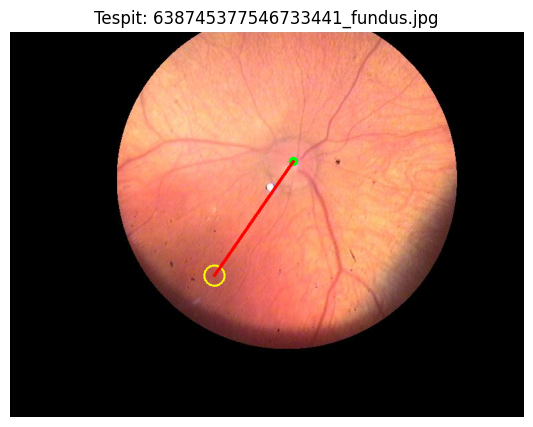

In [4]:
# 3. Adım: Test ve Görselleştirme (Hata Korumalı Versiyon)
img_dir = r"C:\Users\Ayberk\Desktop\vessel_segment_bebek_data\val\image"

# Klasörün varlığını kontrol et
if not os.path.exists(img_dir):
    print(f"Hata: {img_dir} yolu bulunamadı! Lütfen yolu kontrol et.")
else:
    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"{len(images)} adet resim bulundu.")

    for img_name in images[:100]: # Test için ilk 5 resim
        path = os.path.join(img_dir, img_name)
        
        # Resmi oku
        img_bgr = cv2.imread(path)
        
        # OKUMA KONTROLÜ: Eğer resim boşsa atla
        if img_bgr is None:
            print(f"Uyarı: {img_name} okunamadı, atlanıyor...")
            continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # İşlemleri yap
        res = process_fundus_v3(img_rgb, model, test_transform, device)
        
        if res:
            out_img = img_rgb.copy()
            # OD'yi işaretle (Yeşil)
            cv2.circle(out_img, res["od_center"], 7, (0, 255, 0), -1)
            # Makulayı işaretle (Sarı)
            cv2.circle(out_img, res["macula_center"], 15, (255, 255, 0), 2)
            # Aradaki vektörü çiz
            cv2.line(out_img, res["od_center"], res["macula_center"], (255, 0, 0), 3)
            
            plt.figure(figsize=(10, 5))
            plt.imshow(out_img)
            plt.title(f"Tespit: {img_name}")
            plt.axis('off')
            plt.show()